# Galaxy Clustering Using Unsupervised Learning

### Objective and Purpose

#### My aim (or *goal*, if we want to exhaust all synonyms here) is to assess whether a clustering machine learning algorithm can group the GALFIT morphological properties of galaxies into physically meaningful subclasses. 

#### Additionally, I would like to explore alternate approaches to measuring the various environmental effects on galaxies in and surrounding the Virgo cluster. One such approach could well be the creation of k Feature Groups using k-means clustering on galaxy morphologies and determining whether certain groups with certain morphologies are more often found in certain environments.

---

#### Why use ML?

##### Galaxies are a entangled bundle of correlated properties, including morphology, star formation, stellar mass, and environment. Complicating matters, each of these properties is a continuous quantity that does not immediately lend itself to discrete categories.

##### k-means clustering is one approach to evaluating where the data suggest those category bounds exist in morphological space for the sample, as well as what additional properties correlate with each group.

##### Unsupervised machine learning, furthermore, identifies these bounds without enforced assumptions beyond the value of k. 

---

#### Data Credits...

##### The galaxy data are taken from the Virgo Filament Survey (VFS; Castignani+2022), a set of catalogs spanning nearly 7000 galaxies in and surrounding the Virgo Cluster. The GALFIT parameters are specifically from the fourth installment of the VFS paper series (Conger+2025).

##### Photometric data are courtesy of the Legacy Survey (www.legacysurvey.org).

##### I generate the star formation rates and stellar masses using an open source, python-based SED fitting tool called CIGALE (https://cigale.lam.fr/).
 
#####

---

### Step Zero: Import ALL of the relevant python modules

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#here we go.
import numpy as np
import pandas as pd
import seaborn as sns

from astropy.table import Table
from matplotlib import pyplot as plt
%matplotlib inline

plt.rcParams['figure.dpi'] = 75   #change printed figure size

import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, f1_score, 
                             classification_report, confusion_matrix)
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

import os
homedir=os.getenv("HOME")

import sys
sys.path.insert(0,'utils')
sys.path.insert(0,'stability_tests')

from clustering_utils import run1_kmeans
from plotting_utils import *
from ARI_test import ari_across_seeds
from RFC_test import run_rfc_comparison

### Step One: Defining the Sample and Features

#### As mentioned above, the data all originate from the VFS catalogs: stellar masses, star formation rates, GALFIT parameters, environment classifications, and photometric properties. I specifically use the following GALFIT parameters as the input features for the ML model:

* Effective Radius (kpc) -- W1, g-band -- kiloparsecs (kpc)
* Sersic Index (unitless) -- W1, g-band -- unitless

##### Effective radius, given by GALFIT in *pixels* but then converted to the more physically meaningful kpc by yours truly, is the radius which encloses 50% of the galaxy's total light. As such, it is also referred to as the half-light radius. If more of the galaxy's light is concentrated in its center, the effective radius will be smaller.

##### Sersic index is a float which, for GALFIT models, spans anywhere from ~1 to the severely unphysical 20. Objects with a higher Sersic index tend to be peakier in the center with a more extended light profile (more elliptical), while lower Sersic indices indicate the galaxy is less peaky in the center and reaches total luminosity more quickly (more disk-like). 

##### W1 is one of four near-infrared channels from the WISE satellite primarily trace the obscured star formation and spatial extent of the dust in galaxy disks. W1 specifically traces infrared emission from old stellar populations. g-band, meanwhile, is optical 'green' from the Legacy Survey and probe the spatial distribution of the stars. In tandem, these features provide a relevant view of the galaxy's morphology.

---

#### I impose the following "input feature" cuts to the VFS sample:
* GALFIT models must both not have a numerical error and not have failed to run entirely
* nser < 6 [though the numerical error filter also reliably vets most > 6 objects, an unphysical nser regime for galaxies]

##### Next, I apply cuts that help to further limit any sample bias present in my pool of galaxies. Firstly, noting the weak but extant correlation between galaxy inclination (i.e., how edge-on vs. face-on the galaxy appears in out line of sight) and GALFIT effective radius, I apply an axis ratio limit that mimics the condition from the Local Cluster Survey (Finn+2023):

* Axis Ratio (b/a) > 0.25

##### Next is a mass completeness limit on the full VFS sample. See the `mass_sfr_completeness.ipynb` notebook for further details on how I evaluated this limit. In essence, smaller/fainter objects nearby are more likely to be detected than smaller/fainter objects far away. Mass completeness limits help ensure that a sample equally represents the range of stellar masses across the full redshift spectrum of the sample, meaning that above this limit a galaxy is detectable both near and far.

* log(Mstar) > 8.15

##### Note that I do NOT impose a direct log(SFR) limit, as I do not incorporate W3 (or any band coupled to SFR) morphology into the feature clustering.

##### I *do*, however, impose a signal-to-noise (SNR) constraint on W3 and NUV, the reason being that these two bands are coupled to SFR and are used for CIGALE SED model fitting. The SNR is a measure of the reliability of the signal, so the existence of a robust flux measurement for either W3 or NUV translates to an unspurious SFR for that galaxy.

* SNR(W3) or SNR(NUV) $\geq$ 5

##### Following the advice of van der Wel et al. (2012), I apply a final SNR cut on W1:

* SNR(W1) $\geq$ 20

##### If there are any galaxies that have bright foreground stars whose flux may interfere with the photometry measurements of central galaxies, we remove those galaxies from the sample as well.

* Postage stamps must not include nearby bright foreground stars

##### Finally, apply interquartile range (IQR) clipping to identify outlier galaxies in feature space. This technique helps to isolate galaxies that require visual inspection to determine whether the models are reliable, despite their having passed every other quality cut detailed above. Using a k-clip of 2, meaning that galaxies beyond twice the 25th percentile and twice the 75th percentile of the feature distribution are flagged as outliers. 41 of the "cleansed sample galaxies" constitute outliers. After manually evaluating every galaxy's W1 and g-band GALFIT models, I determined that 32/41 of the outliers are true WISEnheimers: their W1 models are unreliable.
* IQR clipped outliers must pass visual inspection

---

### Step Two: K-means Clustering

#### K-means is an unsupervised machine learning algorithm which partitions data into k feature groups in N-dimensional space, where N is the number of input features.

#### The script will identify k cluster centroids and assign each data point to the nearest centroid as measured by Euclidean distance $\sqrt{(x_k-x_1)^2 + (y_k-y_2)^2 + ... + (z_k-z_n)}$

#### As written above, my input features are the Sersic indices and effective radii in g-band and W1. That is, the number of dimensions is N=4. 

#### Both Step One and Step Two are encompassed by the run_kmeans() function of kmeans_pipeline.py.

#### I will be using k=3 to categorize our sample. This decision is quantifiably justified in Step Four, even though the foremost impetus for k=3 was trial and error.

Note:
* CRE_g = g-band effective radius
* CN_g = g-band sersic index
* CRE_W1-fixBA = W1 effective radius (models made using r-band position angle and axis ratio)
* CN_W1-fixBA = W1 sersic index (models made using r-band position angle and axis ratio)

In [3]:
df = run_kmeans(colors=False)   #if colors=True, then k-means will also use photometric colors for clustering

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_W1-fixBA', 'CN_g', 'CN_W1-fixBA']

ALERT! Removed 925 galaxies after applying the W3, NUV SNR limit.
ALERT! Removed 126 galaxies after applying the W1 SNR limit.
ALERT! Removing 98 galaxies with no GALFIT fit.
ALERT! Removing 502 with GALFIT nser > 6 in one of the bands used for k-means clustering.
ALERT! Removing 152 with a GALFIT numerical error.
ALERT! Removing 103 galaxies with a nearby bright star.
Applying the following completeness limits: logMstar > 8.15, logSFR > None
ALERT! Removing 1791 which do not pass any Mstar, SFR completeness limits specified in init_parameters.txt
ALERT! Removed 364 galaxies after applying the inclination cut.
ALERT! Removed 43 galaxies after excluding VFIDs from init_parameters.py.
#####################################################################
Removed 4104/6780  galaxies in total. This leaves 2676 galaxies. Wow.
#####################################################################


A copy of unscaled/scaled galaxy features was written to data/kmeans_feature_data.csv!

Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...


A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/kmeans_median_features.csv.

Now we have the data table needed to generate science plots!

### Step Three: The Science Plots

In [4]:
from clustering_utils import pca_2d

from init_parameters import Params
params = Params()

Let's first visualize the feature clusters in PCA space.

The vector plot shows the composition of the two principal components. All four have contribute comparably, with the Sersic indices pointing upward while the effective radii point downward.

Feature clusters in PCA space are displayed underneath the vector plot. Evidently, FC0 is most compact and contains the most galaxies, whereas FC1 and FC2 capture more scatter. As we will later observe, this scatter is not arbitrarily assigned.

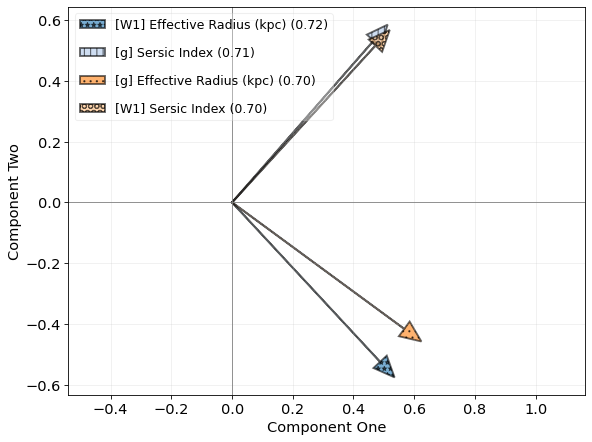

{0: 'FC0 (1855)', 1: 'FC1 (376)', 2: 'FC2 (445)'}


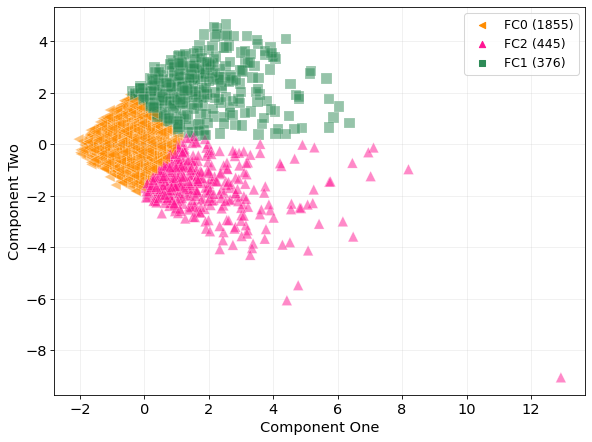

In [5]:
df = pca_2d(df, features=['CRE_g', 'CRE_W1-fixBA', 'CN_g', 'CN_W1-fixBA'], plot=True)
plot_clusters(df, x=df['Comp1'], y=df['Comp2'], PCA=params.PCA_FOR_PLOTTING)

I next assess how median physical properties of the galaxies in these feature clusters compare. In addition to the four features used for k-means, I check the W3/W1 size ratios, NUV-r colors, and W1-W3 colors.

* NUV-r measures the amount of unobscured star formation in a galaxy by comparing its young (NUV) vs. old (r-band) stellar populations. Lower values mean younger stars (more recent star formation), lower values mean the stars are generally older (quenched star formation).

* W1-W3 measures the dustiness of a galaxy. A higher value means more dusty, a lower values means its infrared color is more so a product of direct stellar emission.
---
* Orange triangles (FC0) -- Small effective radii and Sersic indices in both bands; size ratio ~ 1; low NUV-r, higher W1-W3 -- **SMALL DISKS**
    * Compact and disky, star-forming
* Green squares (FC1) -- Small effective radii and highest Sersic indices in both bands; median size ratio ~ 0.8; HIGH NUV-r and LOW W1-W3 -- **SPHEROIDS**
    * Relatively small early-type ellipticals, truncated W3 emission and low obscured (W3) & unobscured (NUV) star formation 
* Pink triangles (FC2) -- Large effective radii and small Sersic indices in both bands; median size ratio ~ 1; low NUV-r, highest W1-W3 -- **LARGE DISKS**
    * large and disky, star-forming

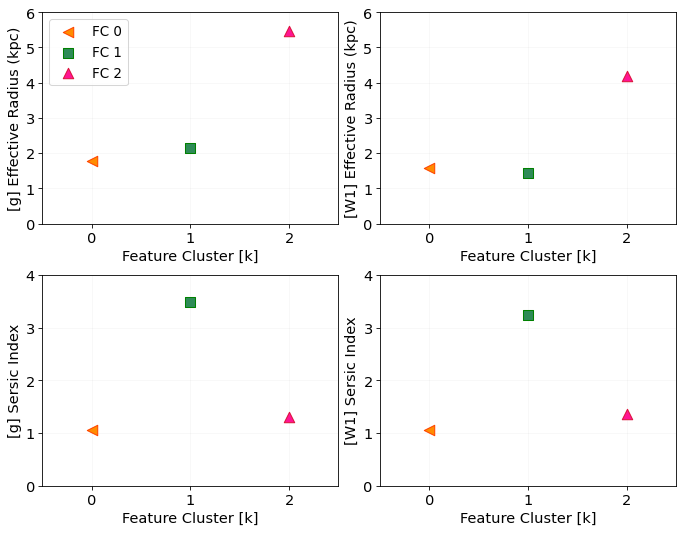

In [7]:
cluster_summary = pd.read_csv('data/kmeans_median_features.csv')
plot_group_features(cluster_summary, layout_dict=params.LAYOUT_DICT)

####################################################################
Using default layout dictionary for median group feature subplots...
####################################################################


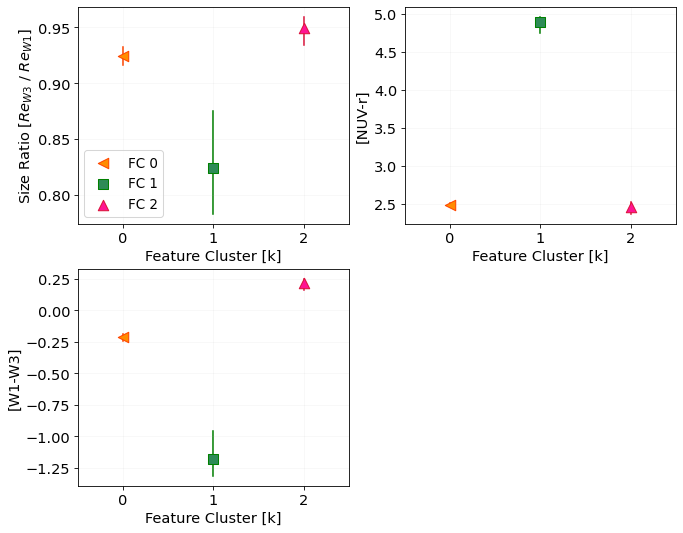

In [8]:
plot_group_features(cluster_summary)

We can also plot these median properties using raincloud plots, which are a conglomeration of a violin plot, a box plot, and a scatterplot.

#########################################
Incoming...expect an output of 4 plot(s).
#########################################


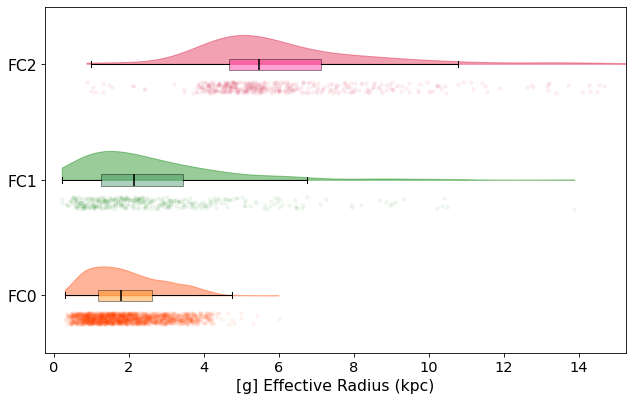

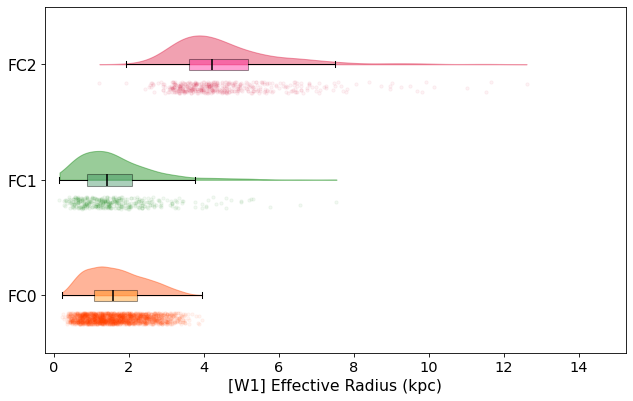

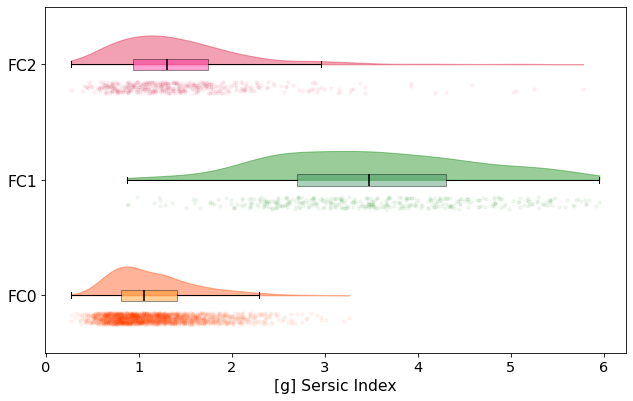

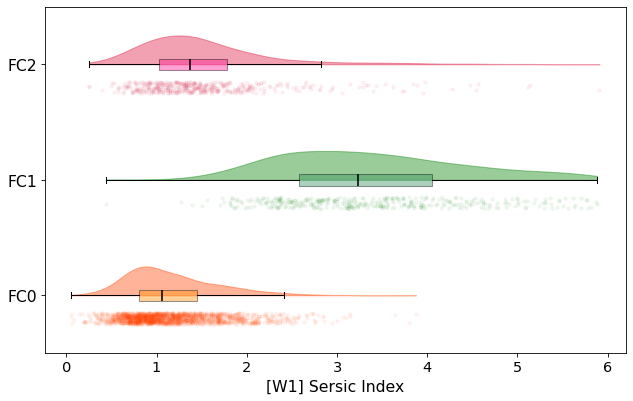

In [9]:
feature_rainclouds(df, feature_list=['CRE_g_unscaled', 'CRE_W1-fixBA_unscaled',
                                     'CN_g_unscaled','CN_W1-fixBA_unscaled'])

#########################################
Incoming...expect an output of 3 plot(s).
#########################################


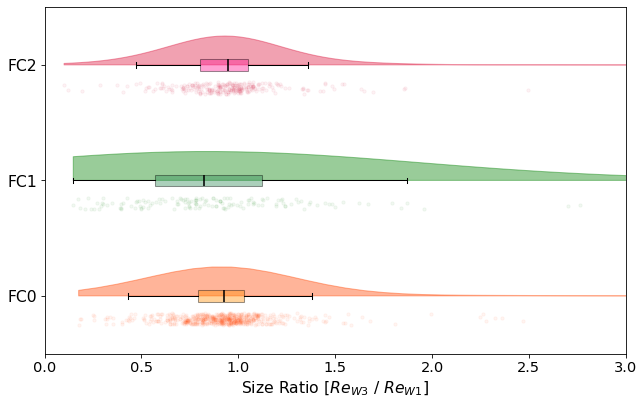

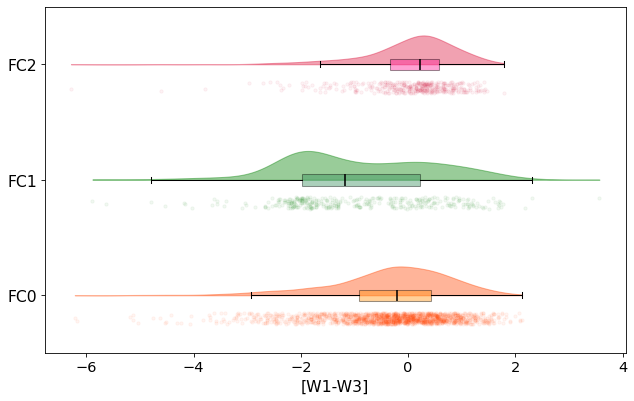

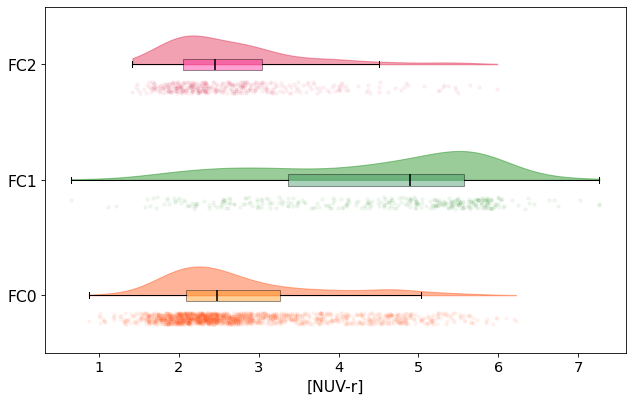

In [10]:
feature_rainclouds(df, feature_list=['Size Ratio','W1_W3','NUV_r'])

There are hints that g-band and W1 morphology has prompted k-means to cluster the galaxies into physically meaningful groups with properties beyond simply morphology. Do we see trends in other regimes, such as star formation rate and stellar mass?

The plot below is of star formation rate (logSFR) vs. stellar mass (logMstar) for the three feature clusters. Multiple lines trace the various completeness limits for the sample -- mass completeness (see above); star formation completeness, were we to implement this limit; and specific star formation rate (sSFR), below which we do not include galaxies in our formulation of the main sequence line. Indeed, the main sequence line represents the regime of typical star forming galaxies in our sample, and galaxies below the sSFR limit are those whose UV and IR emission otherwise associated with star formation is likely dominated by other sources (Salim+2018). 

* Orange peaks at low masses and primarily lies on the main sequence. Many also lie in the low SFR regime.

* Green spans low and high stellar mass, with a larger population at the high mass regime. Most of the galaxies fall below the main sequence line.

* Pink also spans the full range of stellar mass but strongly peaks at high SFR.

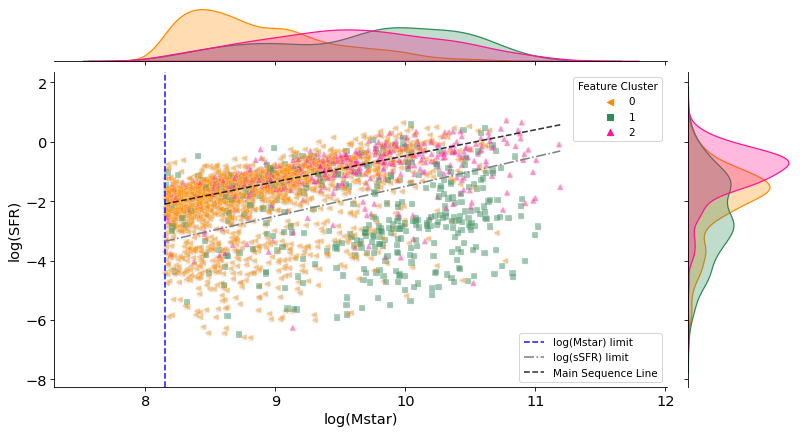

In [11]:
plot_sfrmstar(df, mstar_lim=8.15, sfr_lim=None, y='logsfr')

We also also assess how the galaxies are distributed with respect to their offset from the main sequence line. Below is the same plot concept, but now with a y-axis representing $\Delta$logSFR = logSFR$_{galaxy}$ - logSFR$_{MS}$. Notice how significantly the green population is shifted toward lower SFRs.

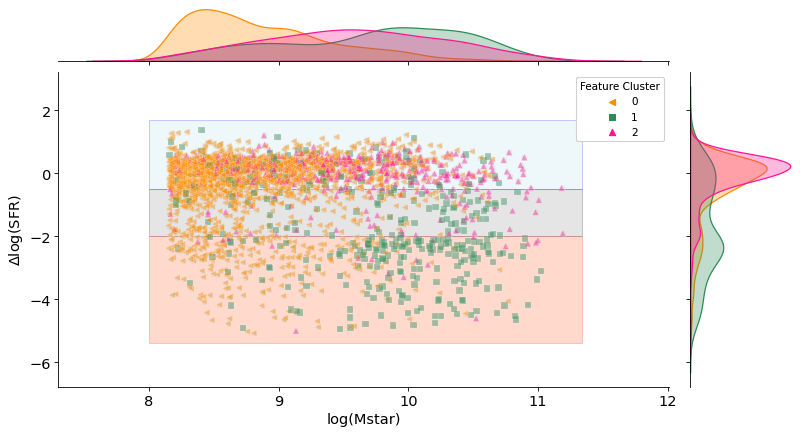

In [12]:
plot_sfrmstar(df, y='delta_logsfr')

We can quantify this shift using K-S tests! This test measures the similarity between distributions, where the "ks stat" refers to the maximum *vertical* distance between the two distributions and the p-value conveys the strength with which the null hypothesis -- that the two distributions are the same -- can be rejected. 

From the numbers printed below, it is rather clear that the comparison of all three feature clusters lends itself to the null hypothesis rejection. One must be careful with relying exclusively on the p-value, however, since there is a negative correlation between p-value and sample size. This may be why the p-value between FG0 and FG2 is so low despite the distributions almost overlapping. 

Even so, the $\Delta$logSFR distribution of FG1 is clearly separable from the rest, with both a high "ks-stat" and looooow p-value (0.00000000000000000000000000000000000000000000000001, at the highest).

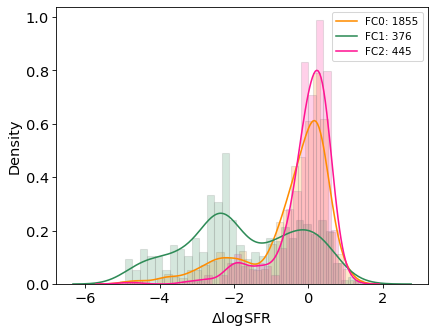

--------------------
ks stat (FG0 & FG1): 0.42873917531685496
p-value (FG0 & FG1): 2.291674054462899e-52
--------------------
--------------------
ks stat (FG0 & FG2): 0.19055695205790604
p-value (FG0 & FG2): 7.011246930852614e-12
--------------------
--------------------
ks stat (FG1 & FG2): 0.5622041596939995
p-value (FG1 & FG2): 6.127597474008147e-60
--------------------


In [13]:
plot_dSFR_KDEs(df)

Next, I explore where these galaxies are housed. That is, are there patterns to be found in the environment composition of these feature groups? Do galaxies in one feature group tend to be more isolated? Do they tend to exist more often in the dense Virgo Cluster?

Legend:
* All Cluster = All galaxies that are members of the Virgo cluster
* Filament & Rich Group = Galaxies that are both in a filament and a rich group (>5 galaxy members)
* Pure Rich Group = Galaxies that are ONLY in a rich group
* Filament & Poor Group = Galaxies that are both in a filament and a poor group (between 2 and 5 galaxy members)
* Pure Poor Group = Galaxies that are ONLY in a poor group
* Pure Filament = Galaxies that are ONLY in a filament
* Pure Field = Galaxies which are isolated

The previous trend of $\Delta$logSFR persists even when partitioned into environments. In each case, FG1 isolates the galaxies that are most below the main sequence -- especially at the densest environments. Also intriguing is that FG1 gradually shifts toward lower $\Delta$logSFR as the environment density increases, whereas this transition is almost abrupt from "Filament & Rich Group" to "All Cluster" for FC0 and FC2. 

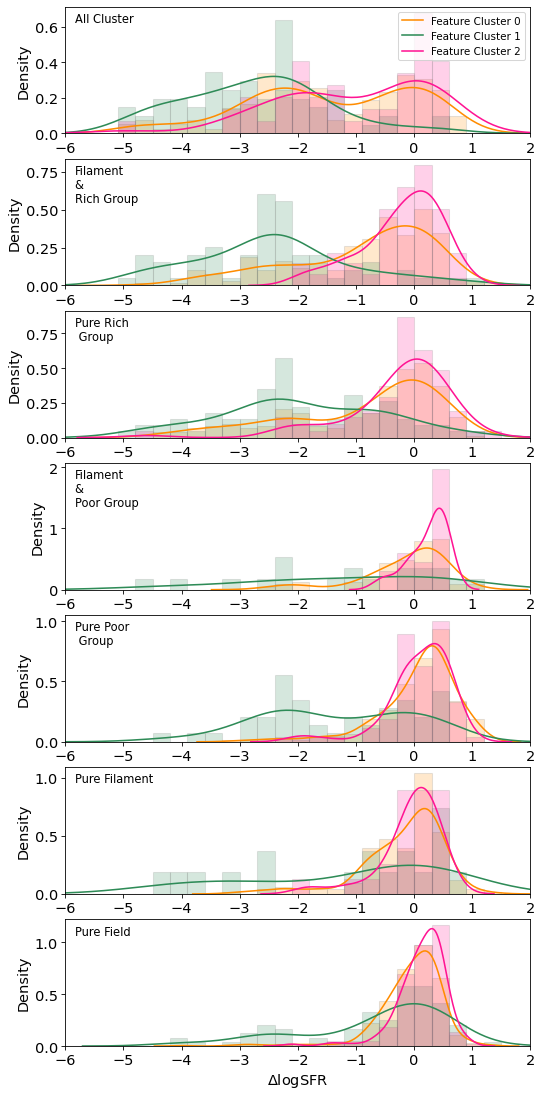

In [32]:
plot_KDE_env(df,w1ser=False,dsfr=True,gser=False,stats=False)

The figure below shows the contribution of each feature cluster to the overall composition of the seven environments, such that summing the points vertically will add to 1. The orange (FG0) of course dominates, since it contains the largest number of galaxies of the three feature clusters. Fascinatingly, FG2 is almost a mirror of FG0's distribution. FG1, meanwhile, follows an almost monotonic decline as the environment becomes less dense, indicating that its representation is highest in the densest environments.

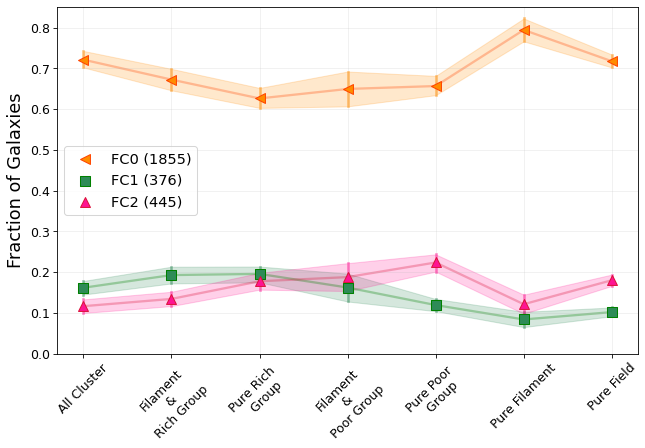

In [15]:
plot_env_fraction(df, main_only=False, envfrac=False, envcomp=True)

---

For this next collection of figures, I divide each feature cluster into three bins according to $\Delta$logSFR:
* main sequence population: -0.5 < $\Delta$logSFR 
* transitioning poulation: -2.0 < $\Delta$logSFR < -0.5
* suppressed population: $\Delta$logSFR < -2.0

I then look at the distribution of Sersic indices in g-band and W1-band for each of these three populations. The general trend of low-to-high Sersic indices from main sequence to suppressed holds for all three feature clusters, as does the overall arrangement of the medians on each set of axes: orange and pink are lowest while green is highest. Pink also rises marginally higher than orange from main sequence to suppressed, though the statistical significance may be negligible.

ms_pop
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...


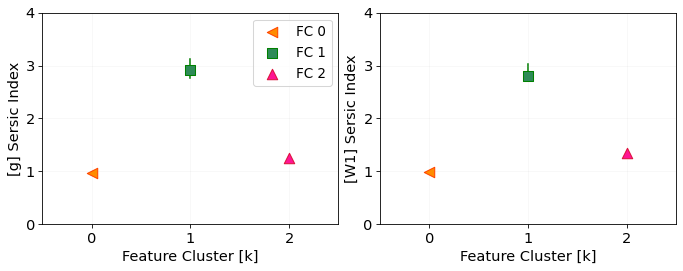

transition_pop
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...


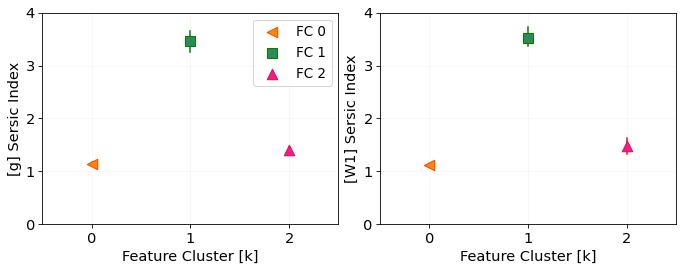

suppressed_pop
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...


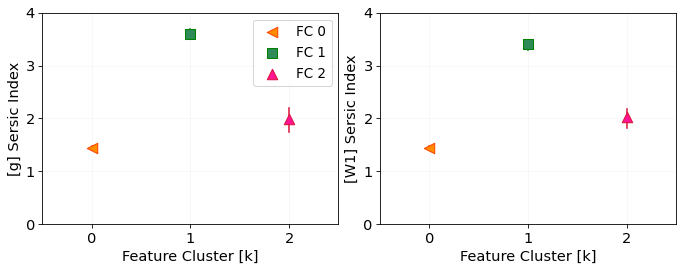

In [16]:
plot_median_nser_pop(df, 3)

For these same $\Delta$logSFR populations, I then check the distribution of Hubble t-type, where negative values indicate a more elliptical galaxy and positive values correspond to a more disk-like morphology. 

* Main sequence -- pink and orange contain much diskier galaxies, while green shows a spread that is more prominent in the negative t-type regime.
* Transition -- pink and orange shift toward lower but still disk-esque morphologies, while green more heavily favors negative t-types.
* Suppressed -- pink is shifted toward negative t-types but still encompasses some late-type galaxies; and orange peaks in a very elliptical regime but also still has some late-types. green, conversely, is almost exclusively t $\leq$ 0. 

Dropping 20 NaN values from ms_pop samples.
#########################################
Incoming...expect an output of 1 plot(s).
#########################################


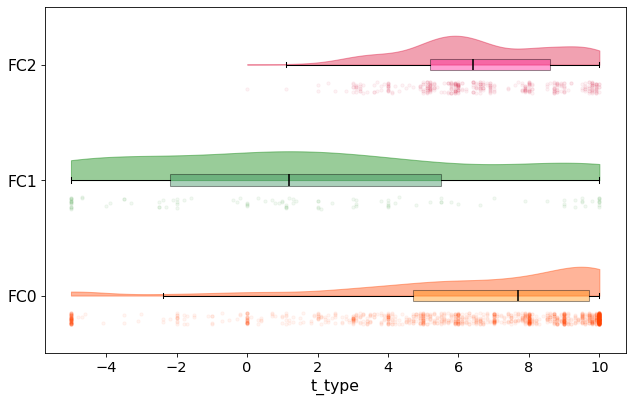

Dropping 0 NaN values from transition_pop samples.
#########################################
Incoming...expect an output of 1 plot(s).
#########################################


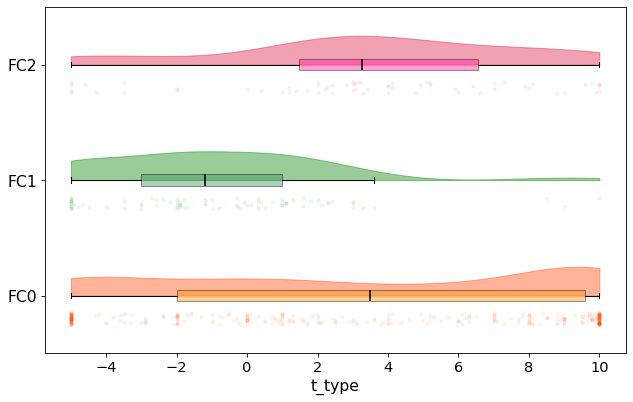

Dropping 0 NaN values from suppressed_pop samples.
#########################################
Incoming...expect an output of 1 plot(s).
#########################################


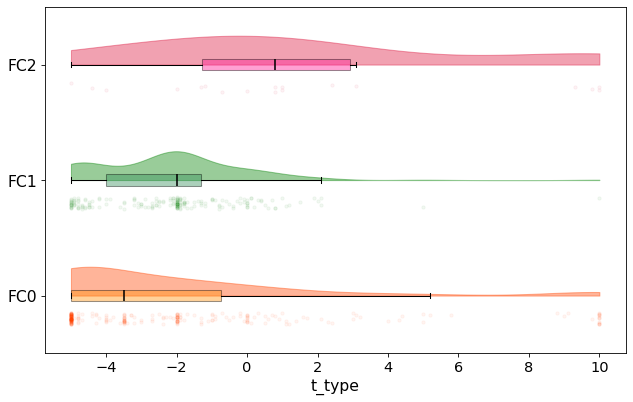

In [17]:
plot_ttype_pop(df, 3)

## Measuring the Robustness of K-Means Feature Groups [k=3]

#### Up until now, I have favored k = 3 as a modeling choice. This section will explore whether some quantitative analysis also justifies the choice.

#### Adjusted Rand Index (ARI)

* ARI is a statistical metric to evaluate the performance of the clustering algorithm, measuring how sensitive the Feature Groups are to the choice of random seed. This index ranges from -1.0 to +1.0, where +1.0 is that every run is indistinguishable from the other (impeccable stability) and -1.0 indicates that the comparisons are so much worse than random chance that you may as well give up (absolutely no stability).

* Take two k-means runs, using k=4. The algorithm will compare galaxy-wise the results between the two runs, counting how many pairs are the same and how many are different. 
    
* The algorithm THEN corrects this fraction correct by subtracting the fraction expected from random labeling. That is, the index accounts (adjusts) for assignments that could be attributed to random chance. This effect is more relevant when the number of k clusters is high, but I use it here regardless.

* Below, I calculate the ARI score for a range of k values [2, 3, 4, 5, 6, 7, 10]. I then run k-means 100 times (n_runs=100), which amounts to using 100 different random seeds. I then print the mean and standard deviation of the 100 runs for every k value.

  * Note I choose n_init=1 for every k-means run, so that I am measuring the intrinsic stability of each Feature Group. Conversely, I use n_init=10 when creating my "science" Feature Groups, which means that every k-means run will have 10 sub-runs and the algorithm will output the "best" of those 10 sub-runs.
  
##### From the printed text below, we see that k=3 yields the highest mean ARI with the lowest standard deviation, suggesting that three Feature Groups not only outperforms the stability of k=2 but the full tested range of k values.

In [33]:
feature_list = ['CRE_g', 'CRE_W1-fixBA',#,'CRE_W3-fixBA',
                  'CN_g', 'CN_W1-fixBA']#, 'CN_W3-fixBA']
X = df[feature_list]

In [35]:
ari_k2 = ari_across_seeds(X, k=2, n_runs=100)
ari_k3 = ari_across_seeds(X, k=3, n_runs=100)
ari_k4 = ari_across_seeds(X, k=4, n_runs=100)
ari_k5 = ari_across_seeds(X, k=5, n_runs=100)
ari_k6 = ari_across_seeds(X, k=6, n_runs=100)
ari_k7 = ari_across_seeds(X, k=7, n_runs=100)
ari_k10 = ari_across_seeds(X, k=10, n_runs=100)

print("k=2 ARI:  mean =", f'{ari_k2.mean():.4f}', " std =", f'{ari_k2.std():.4f}')
print("k=3 ARI:  mean =", f'{ari_k3.mean():.4f}', " std =", f'{ari_k3.std():.4f}')
print("k=4 ARI:  mean =", f'{ari_k4.mean():.4f}', " std =", f'{ari_k4.std():.4f}')
print("k=5 ARI:  mean =", f'{ari_k5.mean():.4f}', " std =", f'{ari_k5.std():.4f}')
print("k=6 ARI:  mean =", f'{ari_k6.mean():.4f}', " std =", f'{ari_k6.std():.4f}')
print("k=7 ARI:  mean =", f'{ari_k7.mean():.4f}', " std =", f'{ari_k7.std():.4f}')
print("k=10 ARI: mean =", f'{ari_k10.mean():.4f}', " std =", f'{ari_k10.std():.4f}')

k=2 ARI:  mean = 0.8696  std = 0.1252
k=3 ARI:  mean = 0.9650  std = 0.0286
k=4 ARI:  mean = 0.6368  std = 0.3178
k=5 ARI:  mean = 0.7774  std = 0.2199
k=6 ARI:  mean = 0.7047  std = 0.1697
k=7 ARI:  mean = 0.6422  std = 0.1578
k=10 ARI: mean = 0.6182  std = 0.1419


## Measuring the Stability of K-means Feature Groups [k=3]

This next section is more of a diagnostic test of the stability of the k=3 feature groups. With an independent machine learning algorithm, are the three Feature Groups reproducible? In particular, can a Random Forest Classification model predict the same Feature Group a galaxy that k-means clustering assigned?

My approach first involved creating a train (60% of the sample) and test (40% of the sample) set of the same input features as with k-means. I use the same dataframe as the k-means script output, to ensure both sample consistency and that I have the column of Feature Clusters. 

In [84]:
#NO DIFFERENCE BETWEEN SCALED AND UNSCALED PARAMETERS FOR RANDOM FOREST CLASSIFICATION!
#output from k-means run is "df"

#define the x (feature_list) and y (feature_clusters) variable names
feature_list = ['CRE_g','CRE_W1-fixBA',
                  'CN_g', 'CN_W1-fixBA']
feature_clusters = ['Feature Cluster']

#define the actual X and y sets. also include the galaxy IDs for visual inspection later on.
#(without VFID, how will I know which galaxy is which?)
#also need the PCA components for plotting the clusters...also later on.
X = df[feature_list]
y = df['Feature Cluster']
VFID = df['VFID']
pcacomp1, pcacomp2 = df['Comp1'], df['Comp2']

In [85]:
#define the training and test sets
#I use 60% of the sample for training and 40% for testing
#random_state ensures reproducibility. can set to any positive integer.
X_train, X_test, y_train, y_test, VFID_train, VFID_test= train_test_split(X, y, VFID,
                                                                          test_size=0.4, 
                                                                          random_state=1, 
                                                                          stratify=y)

Next, I set up the Random Forest Classification model scaffold with the following hyperparameters: 

* n_estimators: the number of decision trees used to create the forest 
* max_depth: dictates maximum complexity (i.e., number of splits) for a decision tree 
* class_weight: quite simply, how the model weighs each class. 'Balanced' automatically assigns weights to each class inversely proportional to their frequency in the data, ensuring the minority class gets more attention.
* max_features: size of the random subsets of features to consider for every decision split (sqrt = sqrt(total number of features) 

I then fit the model to the training data and use the result to predict the Feature Groups (classes) of the test dataset.

In [86]:
#model scaffold
model = RandomForestClassifier(n_estimators=10, max_depth=14,class_weight='balanced',
                               random_state=4,max_features='sqrt')

In [87]:
#train the model...
model.fit(X_train, y_train)

,n_estimators,10
,criterion,'gini'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
#predict Feature Groups (classes) of test dataset
y_pred = model.predict(X_test)

Now that we have our predictions, we can perform some diagnostics. The first is accuracy, which is merely a percentage of the number of correct predictions.

In [89]:
accuracy = (np.sum(np.diag(confusion_matrix(y_test, y_pred)))) / (np.sum(confusion_matrix(y_test, y_pred))) 
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 98.08%


~98% is high! Let's try to decompose this score to see where the model hiccuped.

Below is a "classification report," detailing the "precision," "recall," and "f1-score" for each of the three Feature Groups (0, 1, 2). Concentrating on the columns for the moment, using Feature Group 1 (FG1) as an example,

* Precision: when the model predicts FG1, how often is it correct?
* Recall: how many of the k-means FG1 galaxies were correctly labeled as FG1? does it miss "actual" FG1 galaxies?
* f1-score: what is the average precision and recall percentage?

Looking at the table below, I immediately notice that FG1 is showing a high precision and a slightly lower recall score: the model predicts FG1 galaxies correctly ~96% of the time but misses "actual" FG1 galaxies more often than for FC0 and FC2. That is, the model fails to capture about 0.5% of "actual" FG2 galaxies, thinking the galaxies belong instead to FC0 or FC2. Given that these scores are nearly all above 0.95, however, this observation is trivial.

In [90]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.987     0.993     0.990       754
           1      0.955     0.949     0.952       157
           2      0.978     0.956     0.967       182

    accuracy                          0.981      1093
   macro avg      0.973     0.966     0.970      1093
weighted avg      0.981     0.981     0.981      1093



The confusion matrix below gives even more of a decomposition, showing the galaxies (mis)classified for each of the three Feature Groups. The rows are the "actual" Feature Groups for FC0 (top) to FC2 (bottom), while the columns are the model-predicted Feature Groups for FC0 (left) to FC2 (right). The diagonal integers are the number of galaxies correctly identified, and the off-diagonal elements indicate how many were misclassified and for what Feature Group. The 6, for instance, shows that 6 of "actual" FC1 galaxies were misclassified as FC0 galaxies.

Overall, Random Forest misclassified only 5% of these FC1 galaxies. The percentages for the other two Feature Groups is even lower.

In [91]:
cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
print(cm)

[[749   3   2]
 [  6 149   2]
 [  4   4 174]]


Perhaps unsurprisingly, the misclassified galaxies largely lie along the border between clusters in PCA space! The figure below is a *reimagined* version of the PCA-space plot of the Feature Clusters, now with a couple of layers. 

The data show the full sample (small colored points); the test sample that the model classified (larger points); and the galaxies classified by k-means as FC1 but misclassified as either FC0 (red open circles) or FC2 (blue open circles).

For consistency purposes, I create a custom colormap mimicking the scheme above so I (and readers) can keep track of Feature Groups between all figures.

In [92]:
#the aforementioned special custom colormap...

import matplotlib.colors as mcolors

colors = ['darkorange','seagreen','deeppink']
cmap = mcolors.ListedColormap(colors)

In [93]:
#grab the full dataframe row-matched to X_test and y_test
df_test = df.loc[X_test.index].copy()

#create two new bool columns incidating the actual FC2 galaxies which the ML model predicts to 
#  be FC0 (FC2_to_0) or (FC1 FC2_to_1)
df_test['FC1_to_0'] = (y_test == 1) & (y_pred == 0)
df_test['FC1_to_2'] = (y_test == 1) & (y_pred == 2)
df_test['FC0_to_2'] = (y_test == 0) & (y_pred == 2)

df_test['FC0_to_1'] = (y_test == 0) & (y_pred == 1)
df_test['FC2_to_1'] = (y_test == 2) & (y_pred == 1)
df_test['FC2_to_0'] = (y_test == 2) & (y_pred == 0)

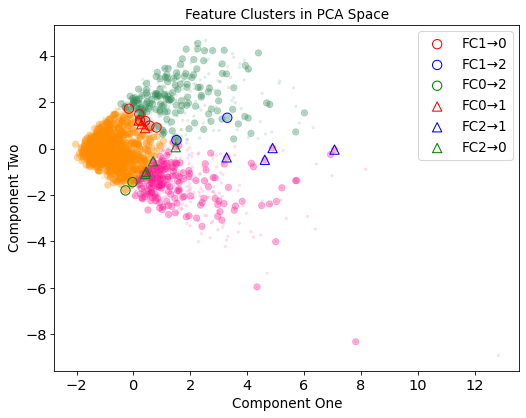

In [94]:
#initialize the figure
plt.figure(figsize=(8,6))

#plot the background points -- all of the galaxy data in PCA space
plt.scatter(df['Comp1'], df['Comp2'], c=df['Feature Cluster'], cmap=cmap, s=5, alpha=0.1)

#plot the test sample that the model classified
plt.scatter(df_test['Comp1'], df_test['Comp2'], c=y_test, cmap=cmap, alpha=0.3)

#add the FC2 --> FC0 overlay (FC2 galaxies which were misclassified as FC0)
plt.scatter(df_test['Comp1'][df_test['FC1_to_0']],
            df_test['Comp2'][df_test['FC1_to_0']],
            facecolors='none', edgecolors='red', s=80, label='FC1→0')

#add the FC2 --> FC1 overlay (FC2 galaxies which were misclassified as FC1)
plt.scatter(df_test['Comp1'][df_test['FC1_to_2']],
            df_test['Comp2'][df_test['FC1_to_2']],
            facecolors='none', edgecolors='blue', s=80, label='FC1→2')

#add the FC0 --> FC2 overlay (FC2 galaxies which were misclassified as FC1)
plt.scatter(df_test['Comp1'][df_test['FC0_to_2']],
            df_test['Comp2'][df_test['FC0_to_2']],
            facecolors='none', edgecolors='green', s=80, label='FC0→2')

plt.scatter(df_test['Comp1'][df_test['FC0_to_1']],
            df_test['Comp2'][df_test['FC0_to_1']],
            facecolors='none', marker='^', edgecolors='red', s=80, label='FC0→1')

plt.scatter(df_test['Comp1'][df_test['FC2_to_1']],
            df_test['Comp2'][df_test['FC2_to_1']],
            facecolors='none', marker='^', edgecolors='blue', s=80, label='FC2→1')

plt.scatter(df_test['Comp1'][df_test['FC2_to_0']],
            df_test['Comp2'][df_test['FC2_to_0']],
            facecolors='none', marker='^', edgecolors='green', s=80, label='FC2→0')

#add legend, axis labels, title.
plt.legend(fontsize=13)
plt.xlabel('Component One',fontsize=13)
plt.ylabel('Component Two',fontsize=13)
plt.title('Feature Clusters in PCA Space',fontsize=13)

plt.show()

We can also take a moment to visually inspect the distribution of points in each Feature Group. Compared with FC0 (orange) especially, FC1 *and* FC2 are less compact with respect to both of the PCA axes. Is this finding quantifiable? Yes, in fact.

We can calculate the average scatter of features relative to their mean, for all galaxies in each of the three Feature Groups (not only the test samples!). Here is some *pseudocode* to articulate the approach:

* For every Feature Group,
    * For every feature column in that Feature Group,
        * Calculate the mean feature value (create a row of averages with length `len(features)`)
    * For every galaxy in that Feature Group,
        * Calculate the difference between that galaxy's features and the corresponding means
        * Square the differences, yielding a Euclidean distance measurement from that galaxy to the k-means
          cluster centroid (in the actual N-dimensional feature space, not PCA space!)
        * Sum each of these terms, the final step in the equation $D^2 = (p_1 - q_1)^2 + (p_2 - q_2) + ...$
    * With the distance squared terms for every galaxy row, calculate the average (this is the mean square radius; the squaring is meant to more strongly penalize larger distances)

This code will output quantative representations of scatter to compare between the three Feature Groups! Note that the choice of Euclidean distance here is largely for...say it with me...internal consistency: since k-means clustering utilizes Euclidean distances, our scatter measures with utilize Euclidean distances.

In [95]:
#convert to numpy arrays so the indices line up
Xv = X.values
yv = y.values

scatter = {}

for k in [0,1,2]:
   

    Xk = Xv[yv == k]       #isolates table rows belonging to Feature Cluster k
                           #written as a numpy matrix. yay.
                           #rows (axis=0) are galaxies, columns (axis=1) are features
    
    mu = Xk.mean(axis=0)   #calculates the mean for all feature columns -- creates array of length len(Features)
                           #Xk.mean() calculates mean of ALL values in Xk
                           #Xk.mean(axis=1) calculates mean for every galaxy row
            
    intercluster_distances = np.sum((Xk - mu)**2, axis=1) #axis=1 means that mu will be subtracted from
                                                          #every galaxy row feature-wise. those individual 
                                                          #row feature values will then be squared, 
                                                          #and finally summed.
                                                          #the result is one squared distance per galaxy.
            
    scatter[f'FG{k}'] = float(f'{np.mean(intercluster_distances):.3f}')   #find average scatter in features.
                                                        #np.mean then calculates the mean squared distance for
                                                        #all of the galaxies in the Feature Group.
print(scatter)

{'FG0': 0.899, 'FG1': 3.496, 'FG2': 4.082}


---

This finding reinforces what our vision spotted: systematically higher scatter in FC1 and FC2. This is additionally reflected in the distribution of stellar masses and even t-types for these Feature Groups -- FC0 knows what it is and knows what it wants.

As we found in the previous section, k-means clustering created a Feature Group (FC1) that happens to harbor the highest fraction of Virgo cluster galaxies and the lowest fraction of field/isolated galaxies of the Feature Groups. Galaxy evolution literature shows that galaxies in high density environments tend to undergo significant morphology transformations (e.g., morphology-density relation; Dressler+1980) due to various galaxy-galaxy and galaxy-environment mechanisms. This, coupled with the Virgo Cluster being relatively young, irregular, and low-mass, is broadly consistent with a diversity of galaxy shapes and sizes among our cluster galaxies...despite trending toward lower size ratios, redder [NUV-r], and more early-type Sersic indices. 

For future work, I would find it exciting to investigate whether this scatter exists as prominently for galaxies in the vicinity of such behemoth structures as the Coma Cluster. I also hope to explore whether k-means clustering has any relevant application to galaxy groups with H-alpha emission, as part of the Virgo Filament Survey collaboration!

## Evaluating the Correlations Between Input Parameters

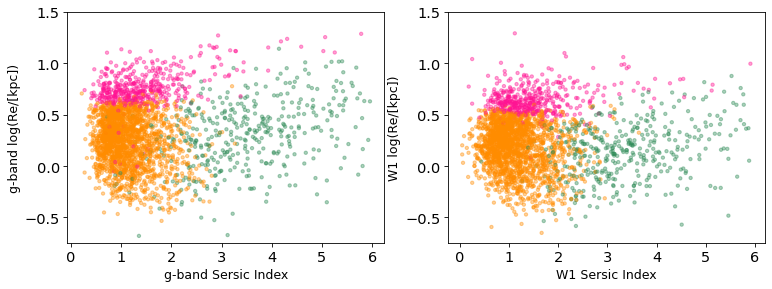

In [96]:
import matplotlib.colors as mcolors
colors = ['darkorange','seagreen','deeppink']
cmap = mcolors.ListedColormap(colors)

plt.subplots(1,2,figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(df['CN_g_unscaled'],np.log10(df['CRE_g_unscaled']),s=10,alpha=0.4,c=df['Feature Cluster'],
           cmap=cmap)
plt.xlabel('g-band Sersic Index',fontsize=12)
plt.ylabel('g-band log(Re/[kpc])',fontsize=12)
plt.ylim(-0.75,1.5)

plt.subplot(1,2,2)
plt.scatter(df['CN_W1-fixBA_unscaled'],np.log10(df['CRE_W1-fixBA_unscaled']),s=10,alpha=0.4,c=df['Feature Cluster'],
           cmap=cmap)
plt.xlabel('W1 Sersic Index',fontsize=12)
plt.ylabel('W1 log(Re/[kpc])',fontsize=12)
plt.ylim(-0.75,1.5)

plt.show()

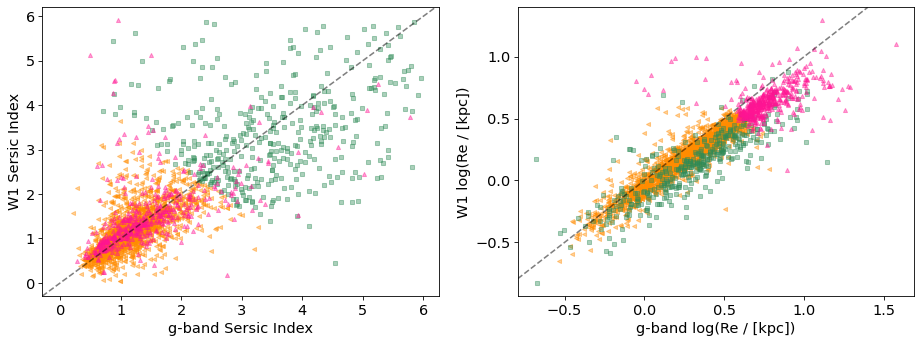

In [97]:
import matplotlib.colors as mcolors
colors = ['darkorange','seagreen','deeppink']
cmap = mcolors.ListedColormap(colors)

markers = ['<', 's', '^']

plt.subplots(1,2,figsize=(15,5))
plt.subplot(1,2,1)

for i in [0,1,2]:
    flag=df['Feature Cluster']==i
    plt.scatter(df['CN_g_unscaled'][flag],df['CN_W1-fixBA_unscaled'][flag],s=15,alpha=0.4,
               color=colors[i], marker=markers[i])

plt.axline([0,0],slope=1,color='black',ls='--',alpha=0.5)
plt.xlabel('g-band Sersic Index',fontsize=14)
plt.ylabel('W1 Sersic Index',fontsize=14)

plt.subplot(1,2,2)

for i in [0,1,2]:
    flag=df['Feature Cluster']==i
    plt.scatter(np.log10(df['CRE_g_unscaled'][flag]),np.log10(df['CRE_W1-fixBA_unscaled'][flag]),
                s=15,alpha=0.4, color=colors[i], marker=markers[i])

plt.axline([0,0],slope=1,color='black',ls='--',alpha=0.5)
plt.xlabel('g-band log(Re / [kpc])',fontsize=14)
plt.ylabel(r'W1 log(Re / [kpc])',fontsize=14)

plt.show()

## Median Size Ratios per Environment using Conger+2025 Figure Template

ALERT! Removed 1711 after limiting W3 SNR > 10. and omitting W3 Numerical Errors.
['Cluster count: 75', 'Rich Group count: 150', 'Poor Group count: 135', 'Filament count: 177', 'Pure Field count: 190']


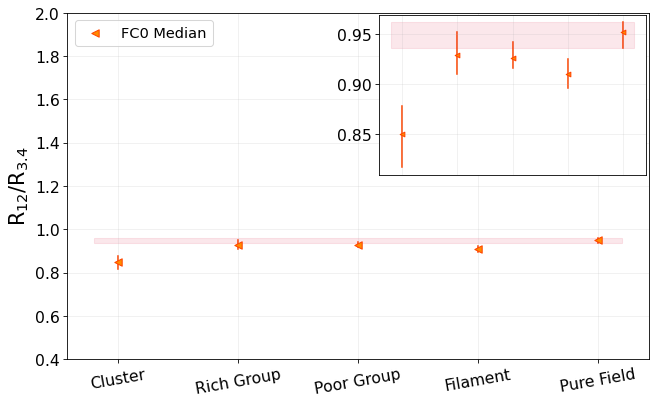

['Cluster count: 33', 'Rich Group count: 58', 'Poor Group count: 29', 'Filament count: 42', 'Pure Field count: 26']


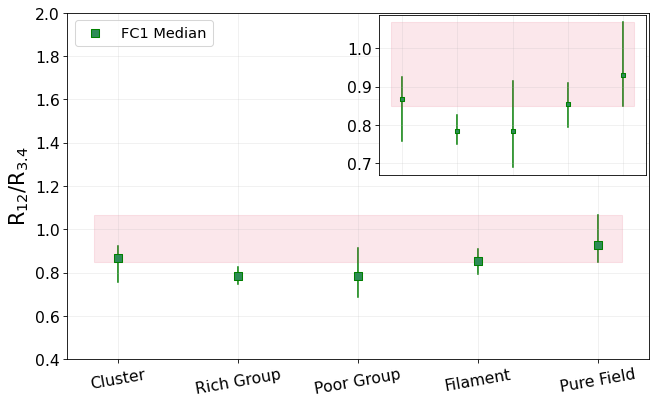

['Cluster count: 21', 'Rich Group count: 82', 'Poor Group count: 81', 'Filament count: 60', 'Pure Field count: 74']


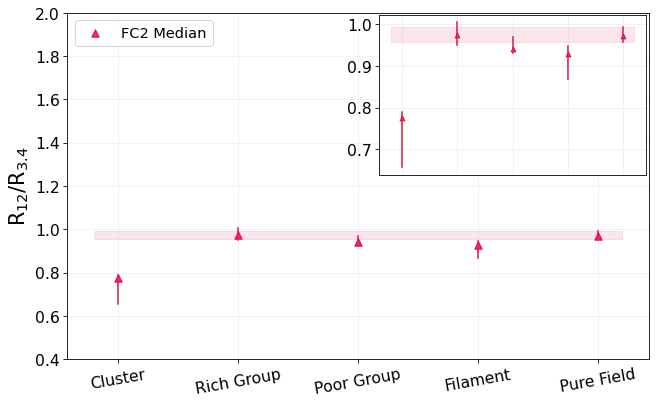

In [128]:
from plotting_utils import virgowise_median_plot
virgowise_median_plot(df)

## HDBSCAN Run (Archived)

HDBSCAN differs from the more Euclidean k-means clustering in that it looks for localized, **discrete** overdensities in feature space. While k-means will force partitions even if they are not physically meaningful, HDBSCAN will not *invent* clusters and performs best when there are potent density contrasts in the data. Also unique to HDBSCAN is that the model will identify its own *cloud* of noisy data, which is analogous to the algorithm saying "idk what to do with these."

HDBSCAN uses the following hyperparameters:
* Minimum cluster size: smallest valid cluster size
* Minimum samples: higher value means smoother landscape and fewer small pockets of dense feature clusters)
* Metric: how the distances between points are calculated; Canberra gives more weight to small distances
* Cluster selection method: captures finer variations that eom (excess of mass) would merge into a single feature clusters

Although galaxy morphologies are indeed not discrete properties, I try HDBSCAN to determine how many unique Feature Groups it might identify without requiring the model to conform to the user's k preference. 

I did write a function in an effort to optimize these hyperparameters. The approach, called Density-Based Clustering Validation (DBCV), outputs a metric to assess the quality of the defined clusters with some configuration of hyperparameters - not unlike the elbow and silhouette methods for k-means clustering. Funnily enough, even the "best" DBCV score for my galaxy data is negative, indicating that my multi-dimensional morphology parameter space is continuous. 

In other words, there are no robust pockets of local density and HDBSCAN categories most galaxies as noise.

---

I instead selected hyperparameters such that the output vaguely resembled the k-means Feature Groups. I keep the results here as a self-serving reference more so than an informative section.

In [104]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_W1-fixBA', 'CN_g', 'CN_W1-fixBA']

ALERT! Removed 925 galaxies after applying the W3, NUV SNR limit.
ALERT! Removed 126 galaxies after applying the W1 SNR limit.
ALERT! Removing 98 galaxies with no GALFIT fit.
ALERT! Removing 502 with GALFIT nser > 6 in one of the bands used for k-means clustering.
ALERT! Removing 152 with a GALFIT numerical error.
ALERT! Removing 6 galaxies with a nearby bright star.
Applying the following completeness limits: logMstar > 8.15, logSFR > None
ALERT! Removing 1812 which do not pass any Mstar, SFR completeness limits specified in init_parameters.txt
ALERT! Removed 373 galaxies after applying the inclination cut.
ALERT! Removed 55 galaxies after excluding VFIDs from init_parameters.py.
#####################################################################
Removed 4049/6780  galaxies in total. This leaves 2731 galaxies. Wow.
#####################################################################


A copy of the scaled galaxy features was written to data/hdb_feature_data.csv!

Calculating medians for Size Ratios -- removing SNR(W3) > 10 galaxies...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...
Calculating medians for colors -- removing invalid entries for NUV-r and W1-W3...


A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/hdbscan_median_features.csv:

5 clusters


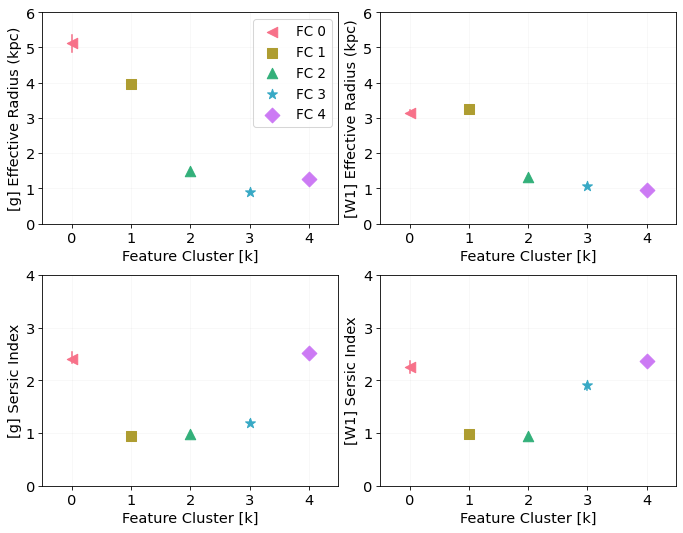

5 clusters
{0: 'FC0 (270)', 1: 'FC1 (460)', 2: 'FC2 (849)', 3: 'FC3 (95)', 4: 'FC4 (339)'}


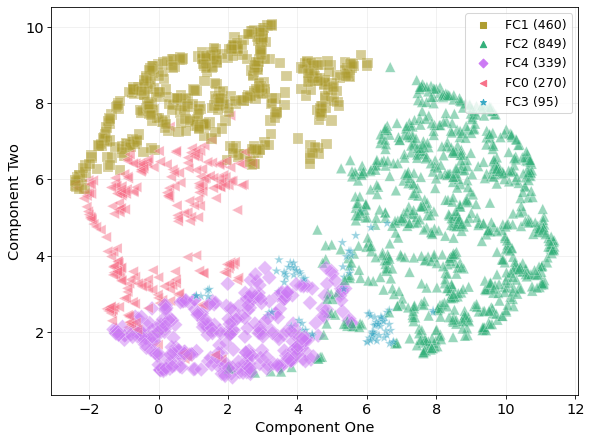

In [115]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan()

## Testbed / Sandbox

#### Miscellaneous Diagnostic Plots

In [119]:
vf_pa = Table.read('data/vf_v2_galfit_r.fits').to_pandas()['CPA']
vf_snr = Table.read('data/virgowise_data.fits').to_pandas()['SNR_phot']

In [120]:
#automatically index matches!
df['CPA'] = vf_pa
df['snr'] = vf_snr

In [121]:
ar0=df['Axis Ratio'][df['Feature Cluster']==0]
ar1=df['Axis Ratio'][df['Feature Cluster']==1]
ar2=df['Axis Ratio'][df['Feature Cluster']==2]

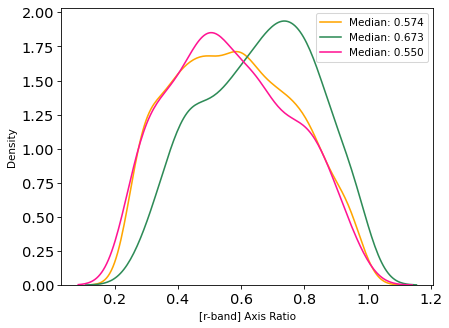

In [122]:
sns.kdeplot(ar0,color='orange',label=f'Median: {np.median(ar0):.3f}')
sns.kdeplot(ar1,color='seagreen',label=f'Median: {np.median(ar1):.3f}')
sns.kdeplot(ar2,color='deeppink',label=f'Median: {np.median(ar2):.3f}')
plt.xlabel('[r-band] Axis Ratio')
plt.legend()
plt.show()

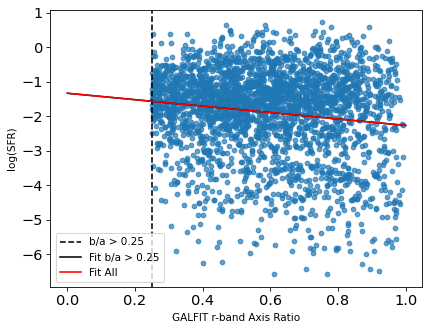

In [123]:
m, b = np.polyfit(df['Axis Ratio'], df['logsfr'], deg=1)

x_flag = ((1 - df['Axis Ratio']) < 0.75)   #df['Axis Ratio'] > 0.25

m_cut, b_cut = np.polyfit(df['Axis Ratio'][x_flag], df['logsfr'][x_flag], deg=1)

x=np.linspace(0,1,100)

plt.scatter(df['Axis Ratio'],df['logsfr'],s=20,alpha=0.7)

plt.axvline(0.25,color='k',ls='--',label='b/a > 0.25')

plt.plot(x,m*x+b,color='black',label='Fit b/a > 0.25')
plt.plot(x, m_cut*x+b_cut, color='red',label='Fit All')

plt.xlabel('GALFIT r-band Axis Ratio')
plt.ylabel('log(SFR)')

plt.legend()
plt.show()

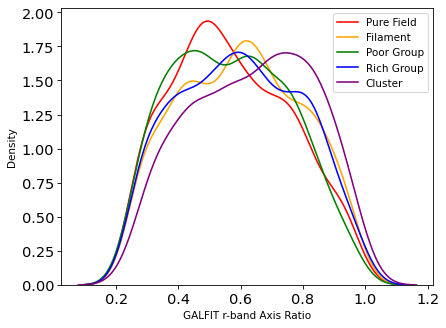

In [124]:
sns.kdeplot(df['Axis Ratio'][df['pure_field']], color= 'red',label='Pure Field') 
sns.kdeplot(df['Axis Ratio'][df['filament_member']], color= 'orange',label='Filament') 
sns.kdeplot(df['Axis Ratio'][df['poor_group_memb']], color= 'green',label='Poor Group') 
sns.kdeplot(df['Axis Ratio'][df['rich_group_memb']], color= 'blue',label='Rich Group') 
sns.kdeplot(df['Axis Ratio'][df['cluster_member']], color= 'purple',label='Cluster') 
#sns.kdeplot (ar1, color= 'seagreen')
#sns.kdeplot (ar2, color='magenta')
#plt.title('W1, optical morphologies')
plt.xlabel('GALFIT r-band Axis Ratio')
plt.legend()
plt.show()

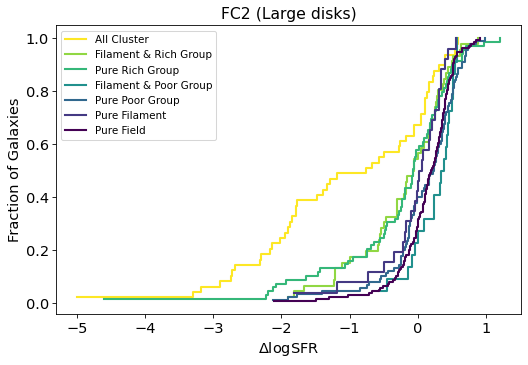

--------------------
ks stat (All Cluster || Filament & Rich Group): 0.404
p-value (All Cluster || Filament & Rich Group): 5.240e-04
--------------------
--------------------
ks stat (All Cluster || Pure Rich Group): 0.359
p-value (All Cluster || Pure Rich Group): 8.105e-04
--------------------
--------------------
ks stat (All Cluster || Filament & Poor Group): 0.542
p-value (All Cluster || Filament & Poor Group): 1.222e-04
--------------------
--------------------
ks stat (All Cluster || Pure Poor Group): 0.473
p-value (All Cluster || Pure Poor Group): 5.632e-07
--------------------
--------------------
ks stat (All Cluster || Pure Filament): 0.451
p-value (All Cluster || Pure Filament): 1.137e-03
--------------------
--------------------
ks stat (All Cluster || Pure Field): 0.508
p-value (All Cluster || Pure Field): 4.369e-09
--------------------
--------------------
ks stat (Filament & Rich Group || Pure Rich Group): 0.087
p-value (Filament & Rich Group || Pure Rich Group): 9.778e-

In [92]:
plot_cum_env(df, fc=2)

#### Analyzing postage stamps of FG0, FG1 in three regimes of the dlogSFR vs. mstar plot.

First, create population columns depending on dSFR bins.

In [18]:
from table_utils import dsfr_columns
from pdf_image_utils import *

import itertools as it

Next, create the actual pdfs...

In [19]:
df = dsfr_columns(df, 3)   #ms_pop, transition_pop, suppressed_pop

In [20]:
#create unique pairs of k and pop. (1,1), (1,2), (1,3), (2,1), etc.
k=[1,2]
pop=[1,2,3]
combs = list(it.product(k, pop))

In [21]:
#define subset for each combination of k and pop. should be len(k) x len(pop) subsets.
subsets = [create_subset(df, k, pop) for k, pop in combs]
subsets = dict(zip(combs, subsets))

In [22]:
#check lengths of each subset, for "sanity" purposes. Most galaxies should be in the MS population.
for key, subset in subsets.items():
    print(f'subset {(key)} length: {len(subset)}\n'
          f'number of pages in pdf: {int( (len(subset)/16) + (1 if len(subset)%16!=0 else 0) )}\n')

subset (1, 1) length: 103
number of pages in pdf: 7

subset (1, 2) length: 83
number of pages in pdf: 6

subset (1, 3) length: 190
number of pages in pdf: 12

subset (2, 1) length: 364
number of pages in pdf: 23

subset (2, 2) length: 63
number of pages in pdf: 4

subset (2, 3) length: 18
number of pages in pdf: 2



In [23]:
df = dsfr_columns(df, 3)   #ms_pop, transition_pop, suppressed_pop
run_all(df, [1,2], [1,2,3], jpg=False, max_workers=1)   #for jpg=False, NO saving JPG images to disk!

k2 suppressed_pop: 100%|██████████| 2/2 [00:21<00:00, 10.75s/it]


In [23]:
df = dsfr_columns(df, 3)   #ms_pop, transition_pop, suppressed_pop
run_all(df, [2], [1,2,3], jpg=False, max_workers=1)   #for jpg=False, NO saving JPG images to disk!

k2 suppressed_pop: 100%|██████████| 2/2 [00:27<00:00, 13.55s/it]


In [24]:
#randomly select 400 rows of FC0 subset, create PDFs using that subset
fc0_subset = df[df['Feature Cluster']==0]
run_all(fc0_subset.sample(n=300), [0], [1,2,3], jpg=False, max_workers=2)   #for jpg=False, NO saving JPG images to disk!

k0 suppressed_pop: 100%|██████████| 3/3 [00:51<00:00, 17.08s/it]
